# Ovarian cancer — survival group classification with Gradient Boosting

Follow-up to `Ovarian_cancer.ipynb`. There the clinical data was classified into
`short_term_survive` (OS ≤ 60 months) vs `long_term_survive` with an L1 logistic regression
(**F1 macro 0.754, Accuracy 0.80** on a single 80/20 split).

In this notebook:
1. Reproduce the original preprocessing and the logistic-regression baseline.
2. Switch to gradient boosting (LightGBM) under the same protocol.
3. Check the protocol for leakage and re-evaluate both models honestly
   (repeated cross-validation, grouped by patient, no target-based imputation).
4. Clean the target (censored patients) and tune LightGBM.
5. Try a "prognosis at diagnosis" variant and adding gene expression.
6. Fit the final model and explain it (feature importance, SHAP values from LightGBM).

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.model_selection import (train_test_split, StratifiedGroupKFold,
                                     cross_validate, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (f1_score, accuracy_score, roc_auc_score, balanced_accuracy_score,
                             classification_report, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42

## 1. Load and preprocess clinical data

Same steps as in `Ovarian_cancer.ipynb` (cells 20–48), collected into one function.
The only additions: `OS_STATUS` is kept aside (needed later to detect censored patients),
and `PATIENT_ID` (first 12 chars of `CASE_ID`) is kept to group samples of the same patient.

In [2]:
pth1 = 'Ovarian_cancer/HGSOC_data/TCGA_DATA_CSV/ClinicalDataCBioportal.csv'
pth2 = 'ClinicalDataCBioportal.csv'
clinical_raw = pd.read_csv(pth1 if os.path.exists(pth1) else pth2, index_col=0, sep=';')
clinical_raw.shape

(617, 61)

In [3]:
STAGE_MAPPING = {'Stage IA': 1, 'Stage IB': 2, 'Stage IC': 3, 'Stage IIA': 4, 'Stage IIB': 5,
                 'Stage IIC': 6, 'Stage IIIA': 7, 'Stage IIIB': 8, 'Stage IIIC': 9, 'Stage IV': 10}


def prepare_clinical(df):
    df = df.copy()
    for col in ['DFS_MONTHS', 'OS_MONTHS', 'FRACTION_GENOME_ALTERED', 'SPECIMEN_SECOND_LONGEST_DIMENSION',
                'SHORTEST_DIMENSION', 'LONGEST_DIMENSION']:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

    df.drop(['OTHER_PATIENT_ID', 'OTHER_SAMPLE_ID', 'PATHOLOGY_REPORT_FILE_NAME', 'PATHOLOGY_REPORT_UUID',
             'HISTORY_OTHER_MALIGNANCY', 'RETROSPECTIVE_COLLECTION', 'SAMPLE_INITIAL_WEIGHT', 'SEX',
             'TREATMENT_OUTCOME_FIRST_COURSE', 'RADIATION_TREATMENT_ADJUVANT', 'PHARMACEUTICAL_TX_ADJUVANT',
             'PROSPECTIVE_COLLECTION', 'OCT_EMBEDDED'], axis=1, inplace=True)

    df['Survival_Group'] = pd.cut(df['OS_MONTHS'], bins=[-float('inf'), 60, float('inf')],
                                  labels=['short_term_survive', 'long_term_survive'])
    df.dropna(subset=['OS_MONTHS'], inplace=True)

    df['CLINICAL_STAGE_NUM'] = df['CLINICAL_STAGE'].map(STAGE_MAPPING)
    df.drop('CLINICAL_STAGE', axis=1, inplace=True)

    df['IS_HISPANIC'] = (df['ETHNICITY'] == 'HISPANIC OR LATINO').astype(int)
    df['IS_VASCULAR_INVASION_INDICATOR'] = (df['VASCULAR_INVASION_INDICATOR'] == 'YES').astype(int)
    df['WITH_TUMOR'] = (df['TUMOR_STATUS'] == 'WITH TUMOR').astype(int)
    df['NEW_TUMOR_AFT_TREAT'] = (df['NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT'] == 'YES').astype(int)
    df['Ashkenazi'] = (df['JEWISH_RELIGION_HERITAGE_INDICATOR'] == 'ASHKENAZI').astype(int)
    df['IS_LYMPHOVASCULAR_INVASION_INDICATOR'] = (df['LYMPHOVASCULAR_INVASION_INDICATOR'] == 'YES').astype(int)

    # kept aside, not used as features
    df['OS_STATUS_INFO'] = df['OS_STATUS']
    df['PATIENT_ID'] = df['CASE_ID'].str[:12]

    df.drop(['LYMPHOVASCULAR_INVASION_INDICATOR', 'VIAL_NUMBER', 'TMB_NONSYNONYMOUS', 'SOMATIC_STATUS',
             'SAMPLE_TYPE_ID', 'SAMPLE_COUNT', 'OS_STATUS', 'ONCOTREE_CODE', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT',
             'IS_FFPE', 'INITIAL_PATHOLOGIC_DX_YEAR', 'INFORMED_CONSENT_VERIFIED', 'ICD_O_3_SITE',
             'ICD_O_3_HISTOLOGY', 'HISTORY_NEOADJUVANT_TRTYN', 'HISTOLOGICAL_DIAGNOSIS', 'FORM_COMPLETION_DATE',
             'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'DAYS_TO_COLLECTION', 'CANCER_TYPE_DETAILED', 'CANCER_TYPE',
             'TISSUE_SOURCE_SITE'], axis=1, inplace=True)

    df = pd.get_dummies(df, columns=['TUMOR_TISSUE_SITE', 'SAMPLE_TYPE', 'RACE', 'PRIMARY_SITE',
                                     'PERFORMANCE_STATUS_TIMING', 'ICD_10', 'ECOG_SCORE', 'DFS_STATUS',
                                     'GRADE', 'RESIDUAL_TUMOR'])
    df.drop(['ETHNICITY', 'VASCULAR_INVASION_INDICATOR', 'TUMOR_STATUS',
             'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'JEWISH_RELIGION_HERITAGE_INDICATOR'], axis=1, inplace=True)
    return df


clinical_data = prepare_clinical(clinical_raw)
print(clinical_data.shape)
clinical_data['Survival_Group'].value_counts()

(599, 58)


Survival_Group
short_term_survive    472
long_term_survive     127
Name: count, dtype: int64

In [4]:
NON_FEATURES = ['OS_MONTHS', 'CASE_ID', 'Survival_Group', 'OS_STATUS_INFO', 'PATIENT_ID']
NUM_WITH_NA = ['DFS_MONTHS', 'FRACTION_GENOME_ALTERED', 'KARNOFSKY_PERFORMANCE_SCORE', 'LONGEST_DIMENSION',
               'MUTATION_COUNT', 'SHORTEST_DIMENSION', 'SPECIMEN_SECOND_LONGEST_DIMENSION', 'CLINICAL_STAGE_NUM']


def get_xy(df):
    X = df.drop(NON_FEATURES, axis=1).astype(float)
    # LightGBM does not accept ':' '/' ' ' etc. in feature names
    X.columns = X.columns.str.replace(r'[^0-9A-Za-z_]+', '_', regex=True)
    y = (df['Survival_Group'] == 'long_term_survive').astype(int)  # 1 = long-term survivor
    groups = df['PATIENT_ID']
    return X, y, groups


X, y, groups = get_xy(clinical_data)
print(X.shape, '| features:', X.shape[1], '| long-term share:', round(y.mean(), 3))
clinical_data[NUM_WITH_NA].isna().sum()

(599, 53) | features: 53 | long-term share: 0.212


DFS_MONTHS                            85
FRACTION_GENOME_ALTERED               17
KARNOFSKY_PERFORMANCE_SCORE          512
LONGEST_DIMENSION                     38
MUTATION_COUNT                       285
SHORTEST_DIMENSION                    38
SPECIMEN_SECOND_LONGEST_DIMENSION     38
CLINICAL_STAGE_NUM                     4
dtype: int64

## 2. Baseline — original protocol, logistic regression

Original protocol:
* missing values filled with the **mean of the survival group** (cell 52),
* single `train_test_split(test_size=0.2, random_state=2021)`,
* `RandomOverSampler` of the minority class on train,
* `interpret.glassbox.LogisticRegression(penalty='l1', solver='liblinear')` — a thin wrapper
  around sklearn's `LogisticRegression`, used directly here.

`RandomOverSampler(sampling_strategy='minority')` is re-implemented in a few lines to avoid the `imblearn` dependency.

In [5]:
def random_oversample(X, y, seed=0):
    rng = np.random.RandomState(seed)
    idx_min = np.where(y == 1)[0]
    idx_maj = np.where(y == 0)[0]
    extra = rng.choice(idx_min, len(idx_maj) - len(idx_min), replace=True)
    idx = np.concatenate([idx_maj, idx_min, extra])
    return X.iloc[idx], y.iloc[idx]


def evaluate(model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    return {'F1_macro': f1_score(y_test, pred, average='macro'),
            'Accuracy': accuracy_score(y_test, pred),
            'Balanced_acc': balanced_accuracy_score(y_test, pred),
            'ROC_AUC': roc_auc_score(y_test, proba)}


# group-mean imputation exactly as in the original notebook
clinical_group_imputed = clinical_data.copy()
group_means = clinical_group_imputed.groupby('Survival_Group', observed=False)[NUM_WITH_NA].transform('mean')
clinical_group_imputed[NUM_WITH_NA] = clinical_group_imputed[NUM_WITH_NA].fillna(group_means)

X_gi, y_gi, _ = get_xy(clinical_group_imputed)
X_train, X_test, y_train, y_test = train_test_split(X_gi, y_gi, test_size=0.20, random_state=2021)
X_train_os, y_train_os = random_oversample(X_train, y_train)
print(X_train.shape, X_test.shape, '-> after oversampling', X_train_os.shape)

lr_orig = LogisticRegression(penalty='l1', solver='liblinear', random_state=2021).fit(X_train_os, y_train_os)

results = {}
results['Original protocol | LogReg'] = evaluate(lr_orig, X_test, y_test)
pd.DataFrame(results).T.round(3)

(479, 53) (120, 53) -> after oversampling (758, 53)


,F1_macro,Accuracy,Balanced_acc,ROC_AUC
Original protocol | LogReg,0.758,0.8,0.818,0.878


## 3. Gradient boosting — same protocol

LightGBM, trained on exactly the same split and oversampled train set.

In [6]:
lgb_orig = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=10,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
                              random_state=SEED, verbose=-1)
lgb_orig.fit(X_train_os, y_train_os)

results['Original protocol | LightGBM'] = evaluate(lgb_orig, X_test, y_test)
pd.DataFrame(results).T.round(3)

,F1_macro,Accuracy,Balanced_acc,ROC_AUC
Original protocol | LogReg,0.758,0.800,0.818,0.878
Original protocol | LightGBM,0.965,0.975,0.971,0.996


### ⚠️ This result is too good — leakage check

A jump from F1 0.76 to ~0.96 on clinical data is suspicious. The reason is the
**group-mean imputation**: a missing value is replaced by the mean of the *target class*.
After that every originally-missing cell holds one of exactly two numbers, and the number itself tells the class.

`KARNOFSKY_PERFORMANCE_SCORE` is missing for 512 / 599 patients, so the imputed value alone
almost perfectly encodes the target. Trees find such exact split points immediately;
the linear model can only partially use them.

KARNOFSKY_PERFORMANCE_SCORE: missing in 512 of 599 rows
Imputed values per class:
Survival_Group
short_term_survive     [75.1219512195122]
long_term_survive     [76.73913043478261]
Name: KARNOFSKY_PERFORMANCE_SCORE, dtype: object

Accuracy of the one-line rule "imputed to long-term mean => long-term" on missing rows: 1.0


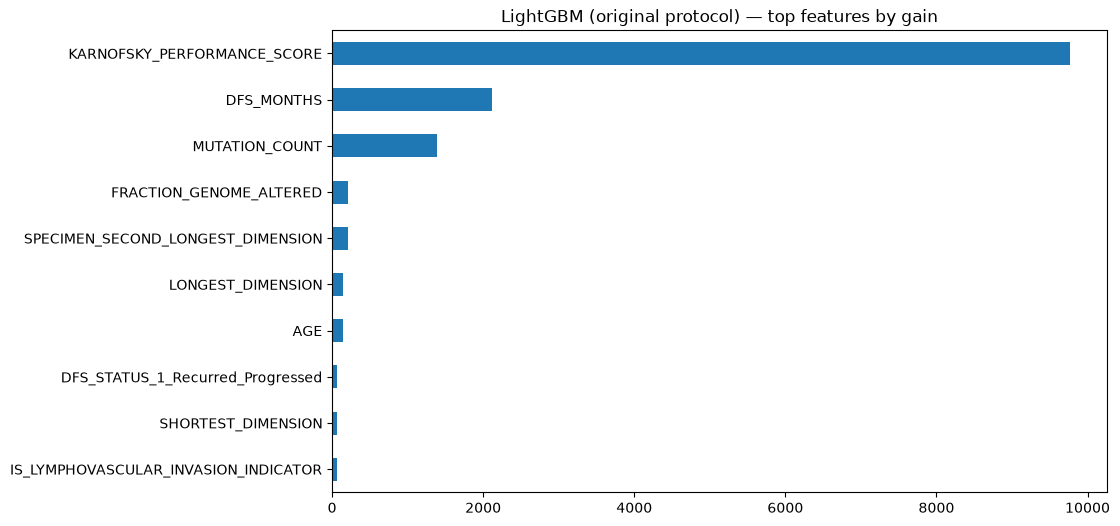

In [7]:
col = 'KARNOFSKY_PERFORMANCE_SCORE'
was_missing = clinical_data[col].isna()
print(f'{col}: missing in {was_missing.sum()} of {len(was_missing)} rows')
print('Imputed values per class:')
print(clinical_group_imputed.loc[was_missing].groupby('Survival_Group', observed=False)[col].unique())

# a single feature "is KARNOFSKY equal to the long-term class mean" already predicts the target
long_mean = clinical_group_imputed.loc[was_missing & (clinical_data['Survival_Group'] == 'long_term_survive'), col].iloc[0]
leak_flag = np.isclose(clinical_group_imputed[col], long_mean).astype(int)
print('\nAccuracy of the one-line rule "imputed to long-term mean => long-term" on missing rows:',
      round(accuracy_score(y[was_missing], leak_flag[was_missing]), 3))

imp = pd.Series(lgb_orig.booster_.feature_importance('gain'), index=X_gi.columns).nlargest(10)
imp.sort_values().plot(kind='barh', title='LightGBM (original protocol) — top features by gain')
plt.show()

Other weaknesses of the original protocol:
* **single split of 120 rows** — the metric changes by several points with another `random_state`;
* **17 patients have two samples** (primary + recurrence) — the same patient can be in train and test;
* imputation statistics are computed on the full dataset, before the split.

## 4. Honest evaluation

* no target-based imputation: logistic regression uses a median imputer fitted inside each fold,
  LightGBM handles `NaN` natively;
* `class_weight='balanced'` instead of oversampling;
* **5-fold `StratifiedGroupKFold` (by patient), repeated 5 times** → mean ± std.

In [8]:
SCORING = {'F1_macro': 'f1_macro', 'Accuracy': 'accuracy', 'Balanced_acc': 'balanced_accuracy', 'ROC_AUC': 'roc_auc'}


def cv_evaluate(model, X, y, groups, n_repeats=5):
    scores = {k: [] for k in SCORING}
    for r in range(n_repeats):
        cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=r)
        out = cross_validate(model, X, y, groups=groups, cv=cv, scoring=SCORING, n_jobs=1)
        for k in SCORING:
            scores[k].extend(out['test_' + k])
    return {k: np.mean(v) for k, v in scores.items()} | {'F1_std': np.std(scores['F1_macro'])}


def make_logreg(C=0.5):
    return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                         LogisticRegression(penalty='l1', solver='liblinear', C=C, class_weight='balanced'))


def make_lgbm(**params):
    base = dict(n_estimators=400, learning_rate=0.02, num_leaves=7, max_depth=3, min_child_samples=15,
                subsample=0.8, subsample_freq=1, colsample_bytree=0.6, reg_lambda=5,
                class_weight='balanced', random_state=SEED, verbose=-1)
    return lgb.LGBMClassifier(**(base | params))


def make_hgb():
    return HistGradientBoostingClassifier(learning_rate=0.03, max_iter=300, max_depth=3, min_samples_leaf=15,
                                          l2_regularization=5, class_weight='balanced', random_state=SEED)


cv_results = {}
for name, model in {'LogReg': make_logreg(), 'LightGBM': make_lgbm(), 'HistGradientBoosting': make_hgb()}.items():
    cv_results[f'All patients | {name}'] = cv_evaluate(model, X, y, groups)
pd.DataFrame(cv_results).T.round(3)

,F1_macro,Accuracy,Balanced_acc,ROC_AUC,F1_std
All patients | LogReg,0.747,0.811,0.782,0.878,0.046
All patients | LightGBM,0.756,0.824,0.782,0.872,0.040
All patients | HistGradientBoosting,0.748,0.820,0.768,0.866,0.037


Without the leak, LightGBM and logistic regression are close — the difference is
far below one standard deviation across folds. Gradient boosting does not get a "free" gain here:
the data is small (~600 rows) and most signal is in a few strong features.

## 5. Cleaning the target: censored patients

`Survival_Group = short_term` means `OS_MONTHS ≤ 60`. But many of these patients are **alive**
at the last follow-up — they were simply observed for less than 5 years. Their real group is unknown,
yet they are labelled "short-term". These rows are label noise; removing them gives a cleaner target.

In [9]:
censored = (clinical_data['OS_MONTHS'] <= 60) & (clinical_data['OS_STATUS_INFO'] == '0:LIVING')
print('Censored before 60 months (alive, label unknown):', censored.sum())
print('Short-term group composition:')
print(clinical_data.loc[clinical_data['Survival_Group'] == 'short_term_survive', 'OS_STATUS_INFO'].value_counts())

clinical_clean = clinical_data[~censored].copy()
X_c, y_c, groups_c = get_xy(clinical_clean)
print('\nClean dataset:', X_c.shape, '| long-term share:', round(y_c.mean(), 3))

Censored before 60 months (alive, label unknown): 174
Short-term group composition:
OS_STATUS_INFO
1:DECEASED    298
0:LIVING      174
Name: count, dtype: int64

Clean dataset: (425, 53) | long-term share: 0.299


In [10]:
for name, model in {'LogReg': make_logreg(), 'LightGBM': make_lgbm(), 'HistGradientBoosting': make_hgb()}.items():
    cv_results[f'Clean target | {name}'] = cv_evaluate(model, X_c, y_c, groups_c)
pd.DataFrame(cv_results).T.round(3)

,F1_macro,Accuracy,Balanced_acc,ROC_AUC,F1_std
All patients | LogReg,0.747,0.811,0.782,0.878,0.046
All patients | LightGBM,0.756,0.824,0.782,0.872,0.040
All patients | HistGradientBoosting,0.748,0.820,0.768,0.866,0.037
Clean target | LogReg,0.771,0.806,0.775,0.855,0.041
Clean target | LightGBM,0.774,0.808,0.778,0.862,0.046
Clean target | HistGradientBoosting,0.768,0.805,0.770,0.856,0.038


### LightGBM hyperparameter tuning

`RandomizedSearchCV` (inner grouped CV) wrapped into the outer repeated CV — **nested CV**,
so the reported score is not biased by the search itself.

In [11]:
PARAM_DIST = {
    'n_estimators': [150, 250, 400, 600],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
    'num_leaves': [3, 5, 7, 11, 15],
    'max_depth': [2, 3, 4, -1],
    'min_child_samples': [5, 10, 15, 25, 40],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.4, 0.6, 0.8, 1.0],
    'reg_lambda': [0, 1, 5, 10, 20],
    'reg_alpha': [0, 0.1, 1],
}


def make_search(n_iter=30):
    return RandomizedSearchCV(make_lgbm(), PARAM_DIST, n_iter=n_iter, scoring='roc_auc',
                              cv=StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED),
                              random_state=SEED, n_jobs=-1)


def nested_cv_evaluate(X, y, groups, n_repeats=3, n_iter=30):
    scores = {k: [] for k in SCORING}
    for r in range(n_repeats):
        outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=r)
        for tr, te in outer.split(X, y, groups):
            search = make_search(n_iter).fit(X.iloc[tr], y.iloc[tr], groups=groups.iloc[tr])
            for k, v in evaluate(search.best_estimator_, X.iloc[te], y.iloc[te]).items():
                scores[k].append(v)
    return {k: np.mean(v) for k, v in scores.items()} | {'F1_std': np.std(scores['F1_macro'])}


cv_results['Clean target | LightGBM tuned (nested CV)'] = nested_cv_evaluate(X_c, y_c, groups_c)
pd.DataFrame(cv_results).T.round(3)

,F1_macro,Accuracy,Balanced_acc,ROC_AUC,F1_std
All patients | LogReg,0.747,0.811,0.782,0.878,0.046
All patients | LightGBM,0.756,0.824,0.782,0.872,0.040
All patients | HistGradientBoosting,0.748,0.820,0.768,0.866,0.037
Clean target | LogReg,0.771,0.806,0.775,0.855,0.041
Clean target | LightGBM,0.774,0.808,0.778,0.862,0.046
Clean target | HistGradientBoosting,0.768,0.805,0.770,0.856,0.038
Clean target | LightGBM tuned (nested CV),0.770,0.802,0.780,0.852,0.043


## 6. Prognosis at diagnosis — without post-treatment features

Several features are **observed after treatment, during follow-up**, and are strongly tied to survival time itself:

| feature | why it is a proxy of the outcome |
|---|---|
| `DFS_MONTHS` | disease-free time is part of the overall survival time |
| `DFS_STATUS_*` | relapse/progression during follow-up |
| `NEW_TUMOR_AFT_TREAT` | new tumour event after treatment |
| `WITH_TUMOR` | tumour status at the last contact |

They are fine for describing the cohort, but a model that should predict survival **at diagnosis**
can not use them. This is the realistic (and much harder) task.

In [12]:
POST_TREATMENT = ['DFS_MONTHS', 'DFS_STATUS_0_DiseaseFree', 'DFS_STATUS_1_Recurred_Progressed',
                  'NEW_TUMOR_AFT_TREAT', 'WITH_TUMOR']
X_c_diag = X_c.drop(columns=POST_TREATMENT)

for name, model in {'LogReg': make_logreg(), 'LightGBM': make_lgbm(), 'HistGradientBoosting': make_hgb()}.items():
    cv_results[f'At diagnosis | {name}'] = cv_evaluate(model, X_c_diag, y_c, groups_c)
pd.DataFrame(cv_results).T.round(3)

,F1_macro,Accuracy,Balanced_acc,ROC_AUC,F1_std
All patients | LogReg,0.747,0.811,0.782,0.878,0.046
All patients | LightGBM,0.756,0.824,0.782,0.872,0.040
All patients | HistGradientBoosting,0.748,0.820,0.768,0.866,0.037
Clean target | LogReg,0.771,0.806,0.775,0.855,0.041
Clean target | LightGBM,0.774,0.808,0.778,0.862,0.046
Clean target | HistGradientBoosting,0.768,0.805,0.770,0.856,0.038
Clean target | LightGBM tuned (nested CV),0.770,0.802,0.780,0.852,0.043
At diagnosis | LogReg,0.620,0.655,0.638,0.684,0.042
At diagnosis | LightGBM,0.615,0.655,0.629,0.678,0.052
At diagnosis | HistGradientBoosting,0.586,0.628,0.600,0.654,0.045


## 7. Adding gene expression


RNA-seq for 421 samples. Expression is `log1p`-transformed, genes expressed in < 50% of samples are dropped,
5000 most variable genes are kept (unsupervised, safe to do on the full set).
The top-*k* genes are then selected by ANOVA F-test **inside each training fold**.

In [13]:
RUN_GENES = True

if RUN_GENES:
    pth1 = 'Ovarian_cancer/HGSOC_data/TCGA_DATA_CSV/GeneExpressionDataTCGA.csv'
    pth2 = 'GeneExpressionDataTCGA.csv'
    gene_expression = pd.read_csv(pth1 if os.path.exists(pth1) else pth2, index_col=0, sep=';', decimal=',')
    genes = np.log1p(gene_expression.T.astype('float32'))
    genes.index = genes.index.str[:15]                       # TCGA-xx-xxxx-01A -> TCGA-xx-xxxx-01
    genes = genes.loc[:, (genes > np.log1p(1)).mean() > 0.5]
    genes = genes[genes.var().nlargest(5000).index]
    print('Gene matrix:', genes.shape)

    clin_genes = clinical_clean.set_index('CASE_ID', drop=False).join(genes, how='inner')
    X_g, y_g, groups_g = get_xy(clin_genes)
    gene_cols = [c for c in X_g.columns if c.startswith('ENSG')]
    clin_cols = [c for c in X_g.columns if c not in gene_cols]
    print('Patients with clinical + expression data:', len(y_g))

    for k in [0, 20, 50]:
        transformers = [('clin', 'passthrough', clin_cols)]
        if k:
            transformers.append(('genes', SelectKBest(f_classif, k=k), gene_cols))
        for name, model in {'LogReg': make_logreg(C=0.1 if k else 0.5), 'LightGBM': make_lgbm()}.items():
            pipe = make_pipeline(ColumnTransformer(transformers), model)
            cv_results[f'Clean + {k} genes | {name}'] = cv_evaluate(pipe, X_g, y_g, groups_g, n_repeats=3)

pd.DataFrame(cv_results).T.round(3)

Gene matrix: (421, 5000)


Patients with clinical + expression data: 305


,F1_macro,Accuracy,Balanced_acc,ROC_AUC,F1_std
All patients | LogReg,0.747,0.811,0.782,0.878,0.046
All patients | LightGBM,0.756,0.824,0.782,0.872,0.040
All patients | HistGradientBoosting,0.748,0.820,0.768,0.866,0.037
Clean target | LogReg,0.771,0.806,0.775,0.855,0.041
Clean target | LightGBM,0.774,0.808,0.778,0.862,0.046
Clean target | HistGradientBoosting,0.768,0.805,0.770,0.856,0.038
Clean target | LightGBM tuned (nested CV),0.770,0.802,0.780,0.852,0.043
At diagnosis | LogReg,0.620,0.655,0.638,0.684,0.042
At diagnosis | LightGBM,0.615,0.655,0.629,0.678,0.052
At diagnosis | HistGradientBoosting,0.586,0.628,0.600,0.654,0.045


With ~300 patients and thousands of candidate genes, the selected genes are mostly noise — scores drop
for both models. A gene signature would need either far more samples or prior biological knowledge
(e.g. published HGSOC prognostic signatures), not a univariate search.

## 8. Final model

LightGBM on the clean target with all clinical features. Hyperparameters come from a grouped
`RandomizedSearchCV` on the training part only; evaluation on a held-out 20% (split by patient).

In [14]:
gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=2021)
train_idx, test_idx = next(gss.split(X_c, y_c, groups_c))
Xtr, Xte, ytr, yte = X_c.iloc[train_idx], X_c.iloc[test_idx], y_c.iloc[train_idx], y_c.iloc[test_idx]
print('train', Xtr.shape, '| test', Xte.shape)

search = make_search(n_iter=40)
search.fit(Xtr, ytr, groups=groups_c.iloc[train_idx])
print('Best inner CV ROC-AUC:', round(search.best_score_, 3))
print(search.best_params_)
final_lgbm = search.best_estimator_

final_lr = make_logreg().fit(Xtr, ytr)

holdout = {'LogReg': evaluate(final_lr, Xte, yte), 'LightGBM tuned': evaluate(final_lgbm, Xte, yte)}
pd.DataFrame(holdout).T.round(3)

train (340, 53) | test (85, 53)


Best inner CV ROC-AUC: 0.882
{'subsample': 0.8, 'reg_lambda': 20, 'reg_alpha': 0, 'num_leaves': 7, 'n_estimators': 150, 'min_child_samples': 10, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


,F1_macro,Accuracy,Balanced_acc,ROC_AUC
LogReg,0.806,0.835,0.806,0.844
LightGBM tuned,0.738,0.765,0.755,0.870


              precision    recall  f1-score   support

  short_term       0.87      0.78      0.82        59
   long_term       0.59      0.73      0.66        26

    accuracy                           0.76        85
   macro avg       0.73      0.76      0.74        85
weighted avg       0.78      0.76      0.77        85



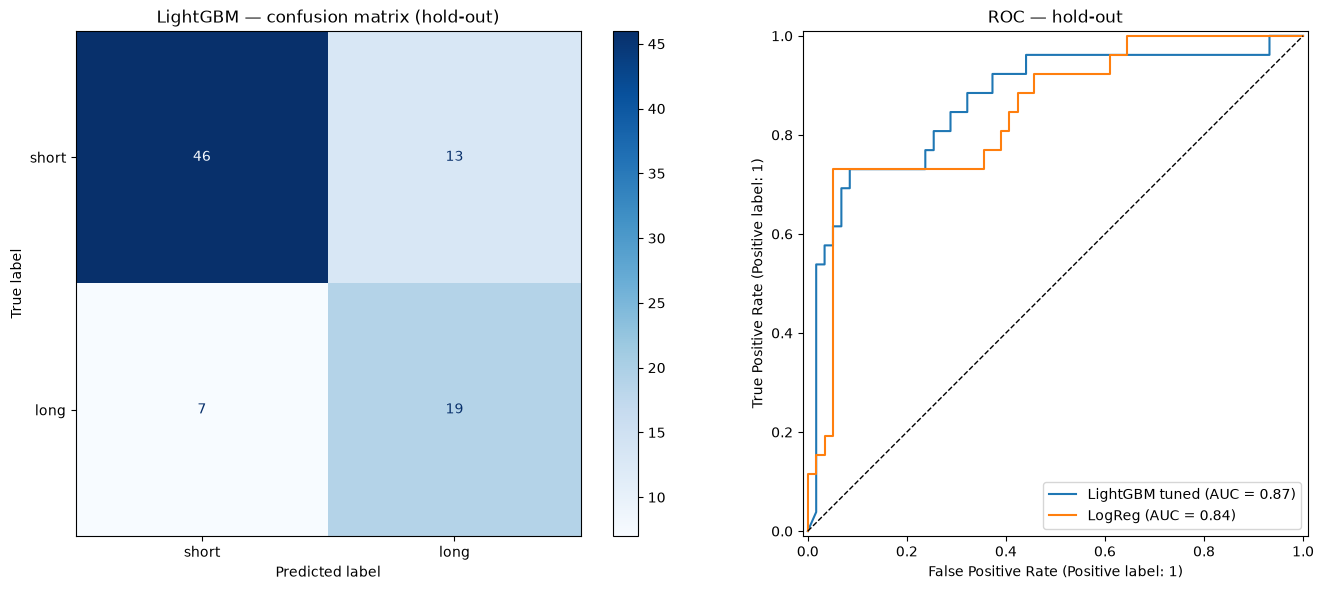

In [15]:
print(classification_report(yte, final_lgbm.predict(Xte), target_names=['short_term', 'long_term']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_estimator(final_lgbm, Xte, yte, display_labels=['short', 'long'],
                                      cmap='Blues', ax=axes[0])
axes[0].set_title('LightGBM — confusion matrix (hold-out)')
RocCurveDisplay.from_estimator(final_lgbm, Xte, yte, name='LightGBM tuned', ax=axes[1])
RocCurveDisplay.from_estimator(final_lr, Xte, yte, name='LogReg', ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC — hold-out')
plt.tight_layout()
plt.show()

On this single hold-out (85 patients, 26 long-term) LightGBM ranks patients better (higher ROC-AUC) but at the
default 0.5 threshold its F1 is lower than logistic regression's. With so few test patients one split can swing
either way — that is exactly why the comparison above is based on repeated CV, not on one split.

### Feature importance and SHAP values

LightGBM computes exact TreeSHAP contributions itself (`pred_contrib=True`), so the `shap` package is not required.
Permutation importance on the hold-out set is shown as a model-agnostic cross-check.

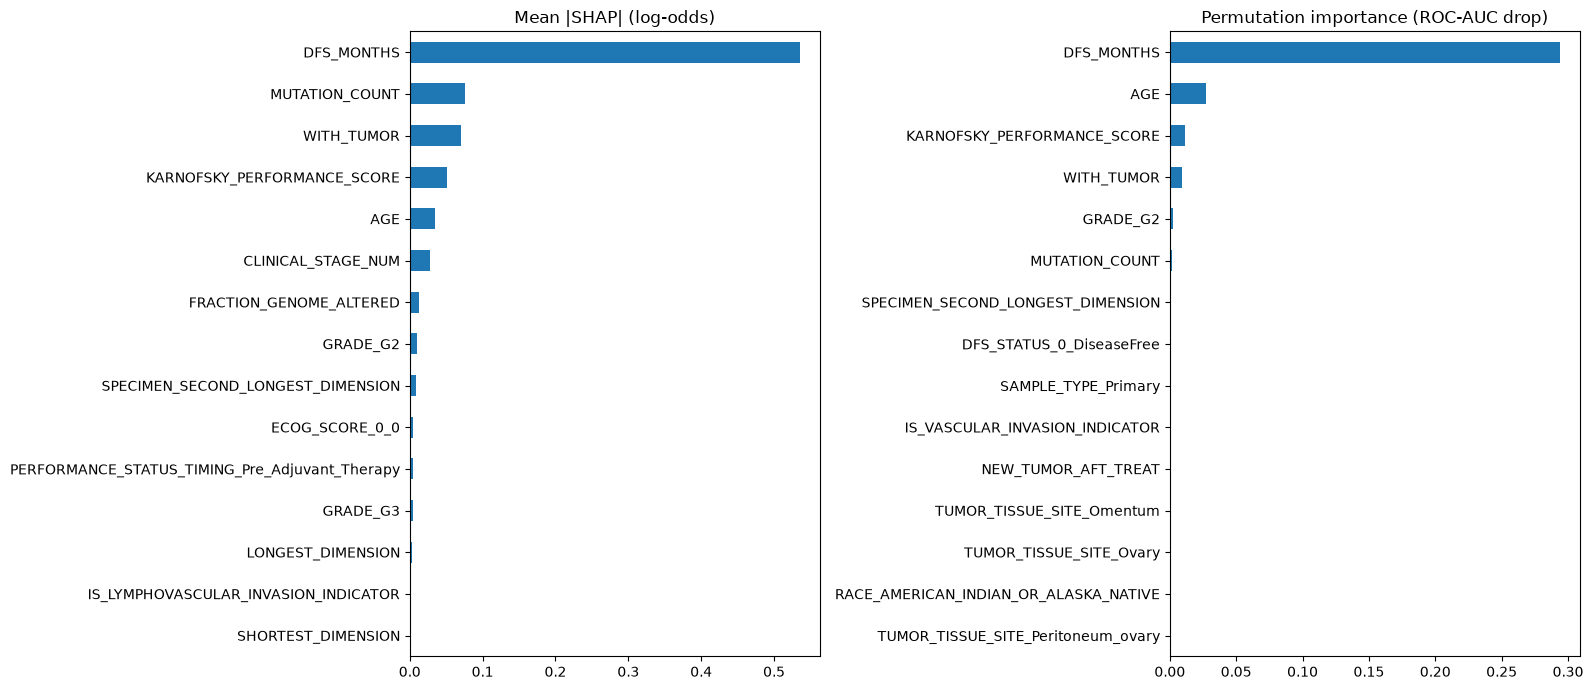

In [16]:
contrib = final_lgbm.predict(Xte, pred_contrib=True)[:, :-1]      # last column = expected value
shap_df = pd.DataFrame(contrib, columns=Xte.columns)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

perm = permutation_importance(final_lgbm, Xte, yte, scoring='roc_auc', n_repeats=30, random_state=SEED)
perm_imp = pd.Series(perm.importances_mean, index=Xte.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
mean_abs_shap.head(15).sort_values().plot(kind='barh', ax=axes[0], title='Mean |SHAP| (log-odds)')
perm_imp.head(15).sort_values().plot(kind='barh', ax=axes[1], title='Permutation importance (ROC-AUC drop)')
plt.tight_layout()
plt.show()

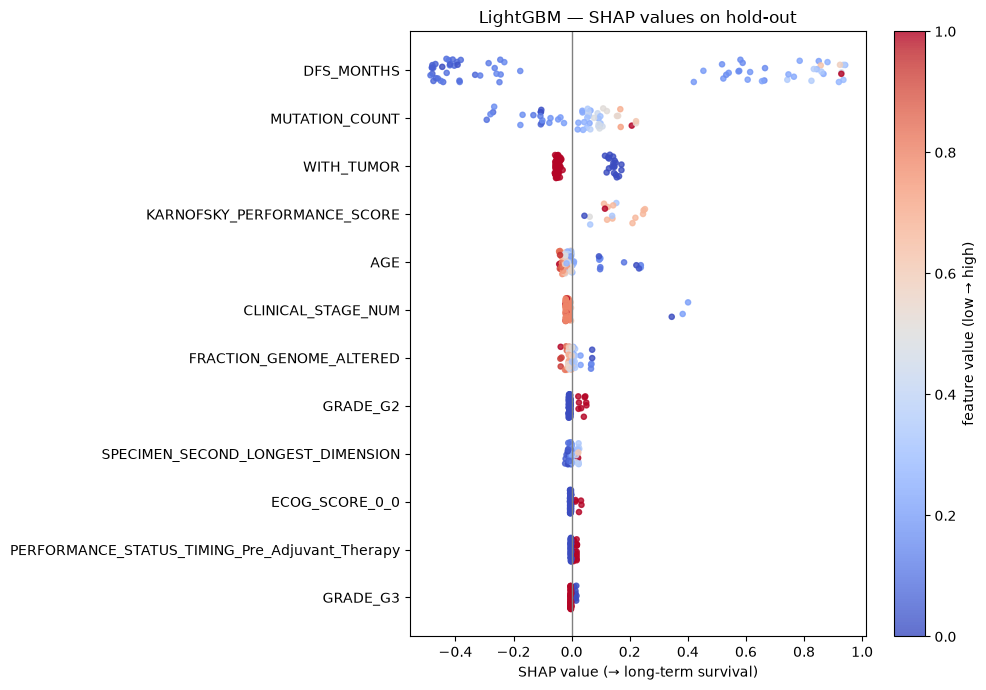

In [17]:
# SHAP "beeswarm"-style plot: direction of the effect for top features
top = mean_abs_shap.head(12).index[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
for i, feat in enumerate(top):
    vals = Xte[feat]
    colour = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    jitter = np.random.RandomState(i).uniform(-0.25, 0.25, len(vals))
    sc = ax.scatter(shap_df[feat], i + jitter, c=colour, cmap='coolwarm', s=14, alpha=0.8)
ax.set_yticks(range(len(top)), top)
ax.axvline(0, color='grey', lw=1)
ax.set_xlabel('SHAP value (→ long-term survival)')
fig.colorbar(sc, ax=ax, label='feature value (low → high)')
plt.title('LightGBM — SHAP values on hold-out')
plt.tight_layout()
plt.show()

## 9. Summary

In [18]:
summary = pd.concat([
    pd.DataFrame(results).T.assign(Protocol='single split, group-mean imputation (leaky)'),
    pd.DataFrame(cv_results).T.assign(Protocol='repeated grouped 5-fold CV'),
])
cols = ['Protocol', 'F1_macro', 'F1_std', 'Accuracy', 'Balanced_acc', 'ROC_AUC']
summary[cols].round(3)

,Protocol,F1_macro,F1_std,Accuracy,Balanced_acc,ROC_AUC
Original protocol | LogReg,"single split, group-mean imputation (leaky)",0.758,NaN,0.800,0.818,0.878
Original protocol | LightGBM,"single split, group-mean imputation (leaky)",0.965,NaN,0.975,0.971,0.996
All patients | LogReg,repeated grouped 5-fold CV,0.747,0.046,0.811,0.782,0.878
All patients | LightGBM,repeated grouped 5-fold CV,0.756,0.040,0.824,0.782,0.872
All patients | HistGradientBoosting,repeated grouped 5-fold CV,0.748,0.037,0.820,0.768,0.866
Clean target | LogReg,repeated grouped 5-fold CV,0.771,0.041,0.806,0.775,0.855
Clean target | LightGBM,repeated grouped 5-fold CV,0.774,0.046,0.808,0.778,0.862
Clean target | HistGradientBoosting,repeated grouped 5-fold CV,0.768,0.038,0.805,0.770,0.856
Clean target | LightGBM tuned (nested CV),repeated grouped 5-fold CV,0.770,0.043,0.802,0.780,0.852
At diagnosis | LogReg,repeated grouped 5-fold CV,0.620,0.042,0.655,0.638,0.684


**Conclusions**

1. **Under the original protocol LightGBM reaches F1 ≈ 0.96 vs 0.76 for logistic regression — but this gain is
   leakage**: the group-mean imputation writes the target into the missing cells (a one-line rule on the imputed
   `KARNOFSKY_PERFORMANCE_SCORE` value is 100% accurate), and trees exploit it.
   The same leak also inflates the original logistic-regression score.
2. **Evaluated honestly** (no target-based imputation, repeated CV grouped by patient), gradient boosting is on par
   with logistic regression: F1 ≈ 0.75–0.78, ROC-AUC ≈ 0.85–0.88 for both. The differences (≈ 0.01) are well
   below the fold-to-fold std (≈ 0.04). Hyperparameter tuning (nested CV) does not add anything either.
3. **Removing censored patients** (174 alive patients with < 5 years of follow-up, labelled "short-term" by mistake)
   makes the target correct; this is the version that should be reported.
4. Most of the predictive power comes from **post-treatment follow-up features** (`DFS_MONTHS`, `DFS_STATUS`,
   `WITH_TUMOR`, `NEW_TUMOR_AFT_TREAT`). Without them — i.e. predicting at diagnosis — ROC-AUC falls to ≈ 0.65–0.68
   for every model.
5. Adding gene expression with in-fold univariate selection **makes results worse** at this sample size.

Bottom line: on this clinical table gradient boosting does not beat a regularised logistic regression; the data
(≈ 400–600 patients, a few strong features) is too small for the extra flexibility to pay off.

**Next steps worth trying**
* treat it as a survival problem (Cox model / `lifelines`, gradient-boosted survival in `scikit-survival`) —
  uses censored patients instead of dropping them;
* use a published HGSOC prognostic gene signature instead of a data-driven gene search;
* report the at-diagnosis model as the clinically meaningful one.